<a href="https://colab.research.google.com/github/SohailVibeCoder/IB9AU---GenAI/blob/main/Task_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name:** Sohail Essajee (5757504)
Training a GAN on floorplan images required switching from simple linear layers to a DCGAN with convolutional layers, since convolutional networks are much better at capturing spatial patterns like walls, rooms, and layouts in images.

With only 1,000 training images the generated floorplans won't be perfect, but techniques like label smoothing and proper weight initialisation helped keep training stable and prevented the Discriminator from overpowering the Generator too early.

The adversarial training process was interesting to observe through the loss curves — ideally both networks improve together, and if one dominates the other, the generated images suffer in quality.

In constract to Task 11 using the Flow Matching, the quality of the floorplans generated was a lot lower using GAN, but this could be due to setting EPOCHS to 50 given the slow running time of the code when using more.

## 1. Install Dependencies & Imports

In [ ]:
%%capture
!pip install torch torchvision matplotlib Pillow

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.10.0
Using device: cpu


## 2. Load & Preview Floorplan Dataset

We create a custom `Dataset` class that loads all `.jpg` images from the floorplan directory. Images are resized to 64×64 (to make training faster and more stable on a small dataset) and normalised to [-1, 1] to match the `Tanh` output of the Generator.

In [ ]:
# ---------- Configuration ----------
DATA_DIR = "floorplans_v2-20251223T170650Z-3-001/floorplans_v2"  # path to floorplan JPGs
IMG_SIZE = 64        # resize images to 64x64 for faster, more stable training
CHANNELS = 3         # RGB images
BATCH_SIZE = 32
LATENT_DIM = 100     # size of the noise vector z
LR = 0.0002          # learning rate (DCGAN standard)
BETA1 = 0.5          # Adam beta1 (DCGAN standard)
EPOCHS = 50         # number of training epochs

# ---------- Custom Dataset ----------
class FloorplanDataset(Dataset):
    """Loads all .jpg images from a directory."""
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = sorted([
            f for f in os.listdir(root_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        print(f"Found {len(self.image_files)} images in {root_dir}")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

# ---------- Transforms ----------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),                          # [0, 1]
    transforms.Normalize([0.5]*3, [0.5]*3),         # [-1, 1]
])

# ---------- DataLoader ----------
dataset = FloorplanDataset(DATA_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

Found 1000 images in floorplans_v2-20251223T170650Z-3-001/floorplans_v2


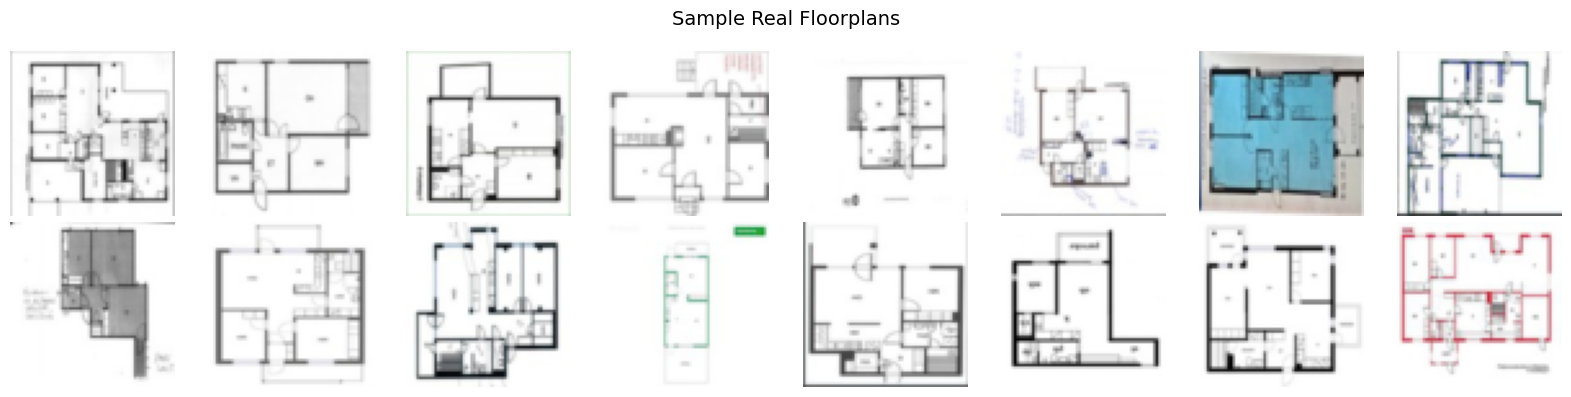

In [ ]:
# ---------- Preview a batch of real floorplans ----------
real_batch = next(iter(dataloader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    # Denormalise from [-1,1] back to [0,1]
    img = real_batch[i].permute(1, 2, 0).numpy() * 0.5 + 0.5
    ax.imshow(img)
    ax.axis('off')
plt.suptitle("Sample Real Floorplans", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Define the DCGAN Architecture

Unlike the simple linear GAN used for MNIST, we use a **Deep Convolutional GAN (DCGAN)** which is far better suited for image data:

- **Generator**: Uses `ConvTranspose2d` (transposed convolution / "deconvolution") layers to progressively upsample a latent noise vector into a 64×64×3 image. Each layer uses `BatchNorm2d` and `ReLU`, with `Tanh` on the final output.
- **Discriminator**: Uses strided `Conv2d` layers to progressively downsample an image into a single real/fake probability. Uses `BatchNorm2d` and `LeakyReLU` throughout, with `Sigmoid` at the end.

Weights are initialised from a normal distribution (mean=0, std=0.02) following the original DCGAN paper.

In [ ]:
# Number of feature maps
NGF = 64   # Generator feature map size
NDF = 64   # Discriminator feature map size

# ---------- Weight Initialisation (DCGAN convention) ----------
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# ---------- Generator ----------
class Generator(nn.Module):
    """
    Maps a latent vector z (LATENT_DIM x 1 x 1) → RGB image (3 x 64 x 64).
    Architecture: 4 transposed-conv blocks + 1 output layer.
    """
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # Input: z (LATENT_DIM x 1 x 1) → (NGF*8 x 4 x 4)
            nn.ConvTranspose2d(LATENT_DIM, NGF * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(NGF * 8),
            nn.ReLU(True),

            # (NGF*8 x 4 x 4) → (NGF*4 x 8 x 8)
            nn.ConvTranspose2d(NGF * 8, NGF * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF * 4),
            nn.ReLU(True),

            # (NGF*4 x 8 x 8) → (NGF*2 x 16 x 16)
            nn.ConvTranspose2d(NGF * 4, NGF * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF * 2),
            nn.ReLU(True),

            # (NGF*2 x 16 x 16) → (NGF x 32 x 32)
            nn.ConvTranspose2d(NGF * 2, NGF, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF),
            nn.ReLU(True),

            # (NGF x 32 x 32) → (3 x 64 x 64)
            nn.ConvTranspose2d(NGF, CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.main(z)

# ---------- Discriminator ----------
class Discriminator(nn.Module):
    """
    Maps an RGB image (3 x 64 x 64) → probability of being real (scalar).
    Architecture: 4 strided-conv blocks + 1 output layer.
    """
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # (3 x 64 x 64) → (NDF x 32 x 32)
            nn.Conv2d(CHANNELS, NDF, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # (NDF x 32 x 32) → (NDF*2 x 16 x 16)
            nn.Conv2d(NDF, NDF * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # (NDF*2 x 16 x 16) → (NDF*4 x 8 x 8)
            nn.Conv2d(NDF * 2, NDF * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # (NDF*4 x 8 x 8) → (NDF*8 x 4 x 4)
            nn.Conv2d(NDF * 4, NDF * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # (NDF*8 x 4 x 4) → (1 x 1 x 1)
            nn.Conv2d(NDF * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.main(img).view(-1, 1)

# ---------- Instantiate & Initialise ----------
G = Generator().to(device)
D = Discriminator().to(device)
G.apply(weights_init)
D.apply(weights_init)

print(f"Generator parameters:     {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator parameters: {sum(p.numel() for p in D.parameters()):,}")

Generator parameters:     3,576,704
Discriminator parameters: 2,765,568


## 4. Training Loop

The training follows the standard DCGAN procedure:

1. **Train Discriminator**: Feed it real floorplans (label ≈ 1) and fake floorplans from the Generator (label ≈ 0). We use **label smoothing** (real labels = 0.9 instead of 1.0) to stabilise training.
2. **Train Generator**: Generate fake floorplans and try to fool the Discriminator into classifying them as real.

A fixed noise vector is kept throughout training so we can visually track how the Generator's output evolves over epochs.

In [ ]:
# ---------- Loss & Optimisers ----------
criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=LR, betas=(BETA1, 0.999))

# Fixed noise for tracking progress visually
fixed_noise = torch.randn(16, LATENT_DIM, 1, 1, device=device)

# ---------- Training ----------
G_losses, D_losses = [], []

print(f"Starting training for {EPOCHS} epochs on {len(dataset)} floorplan images...")
print(f"Batches per epoch: {len(dataloader)}\n")

for epoch in range(1, EPOCHS + 1):
    for i, real_imgs in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)

        # Labels with smoothing
        real_labels = torch.full((bs, 1), 0.9, device=device)
        fake_labels = torch.zeros(bs, 1, device=device)

        # ---- Train Discriminator ----
        optimizer_D.zero_grad()

        # Real images
        output_real = D(real_imgs)
        loss_D_real = criterion(output_real, real_labels)

        # Fake images
        z = torch.randn(bs, LATENT_DIM, 1, 1, device=device)
        fake_imgs = G(z)
        output_fake = D(fake_imgs.detach())
        loss_D_fake = criterion(output_fake, fake_labels)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        optimizer_D.step()

        # ---- Train Generator ----
        optimizer_G.zero_grad()
        output = D(fake_imgs)
        loss_G = criterion(output, torch.ones(bs, 1, device=device))
        loss_G.backward()
        optimizer_G.step()

    # Record losses
    G_losses.append(loss_G.item())
    D_losses.append(loss_D.item())

    # Print progress every 10 epochs
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch [{epoch:3d}/{EPOCHS}]  Loss_D: {loss_D.item():.4f}  Loss_G: {loss_G.item():.4f}")

print("\nTraining complete!")

Starting training for 50 epochs on 1000 floorplan images...
Batches per epoch: 31

Epoch [  1/50]  Loss_D: 1.2807  Loss_G: 12.1047
Epoch [ 10/50]  Loss_D: 0.9334  Loss_G: 1.0828
Epoch [ 20/50]  Loss_D: 0.4496  Loss_G: 4.9609
Epoch [ 30/50]  Loss_D: 0.4392  Loss_G: 5.4798
Epoch [ 40/50]  Loss_D: 0.6187  Loss_G: 1.9515
Epoch [ 50/50]  Loss_D: 0.4695  Loss_G: 4.3970

Training complete!


## 5. Training Loss Curves

Plotting the Generator and Discriminator losses over epochs helps diagnose training stability. Ideally both losses should fluctuate around similar values without one dominating the other.

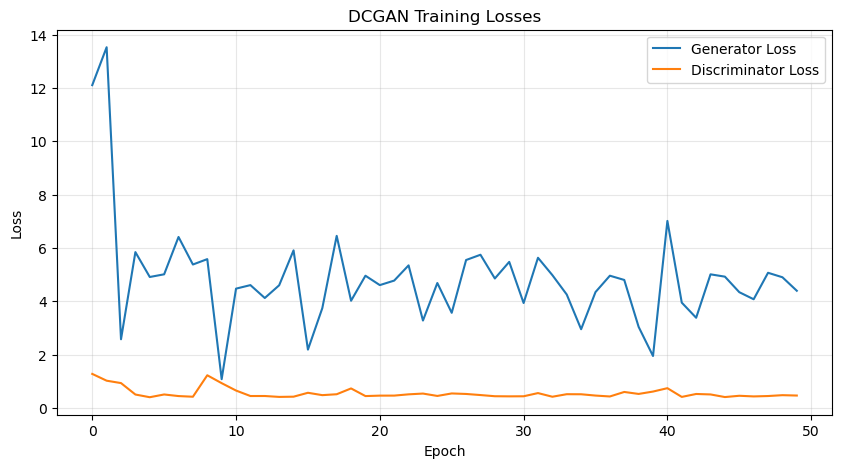

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(G_losses, label='Generator Loss')
plt.plot(D_losses, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DCGAN Training Losses')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Generate Synthetic Floorplans

Using the trained Generator, we sample random noise vectors and produce new floorplan images that the model has never seen before. These are entirely synthetic — generated from learned patterns in the training data.

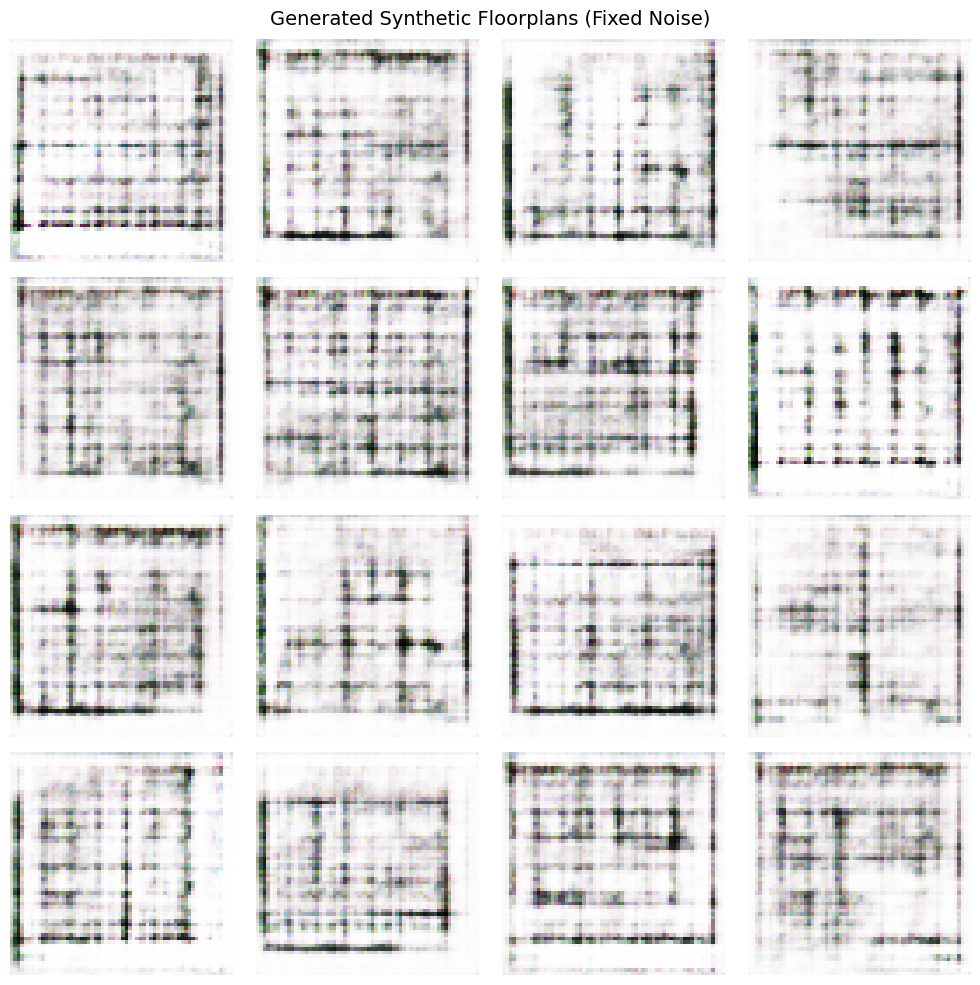

In [ ]:
# Generate 16 synthetic floorplans using the fixed noise (to see final training result)
G.eval()
with torch.no_grad():
    generated = G(fixed_noise).cpu()

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    img = generated[i].permute(1, 2, 0).numpy() * 0.5 + 0.5  # Denormalise to [0,1]
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.axis('off')
plt.suptitle("Generated Synthetic Floorplans (Fixed Noise)", fontsize=14)
plt.tight_layout()
plt.show()

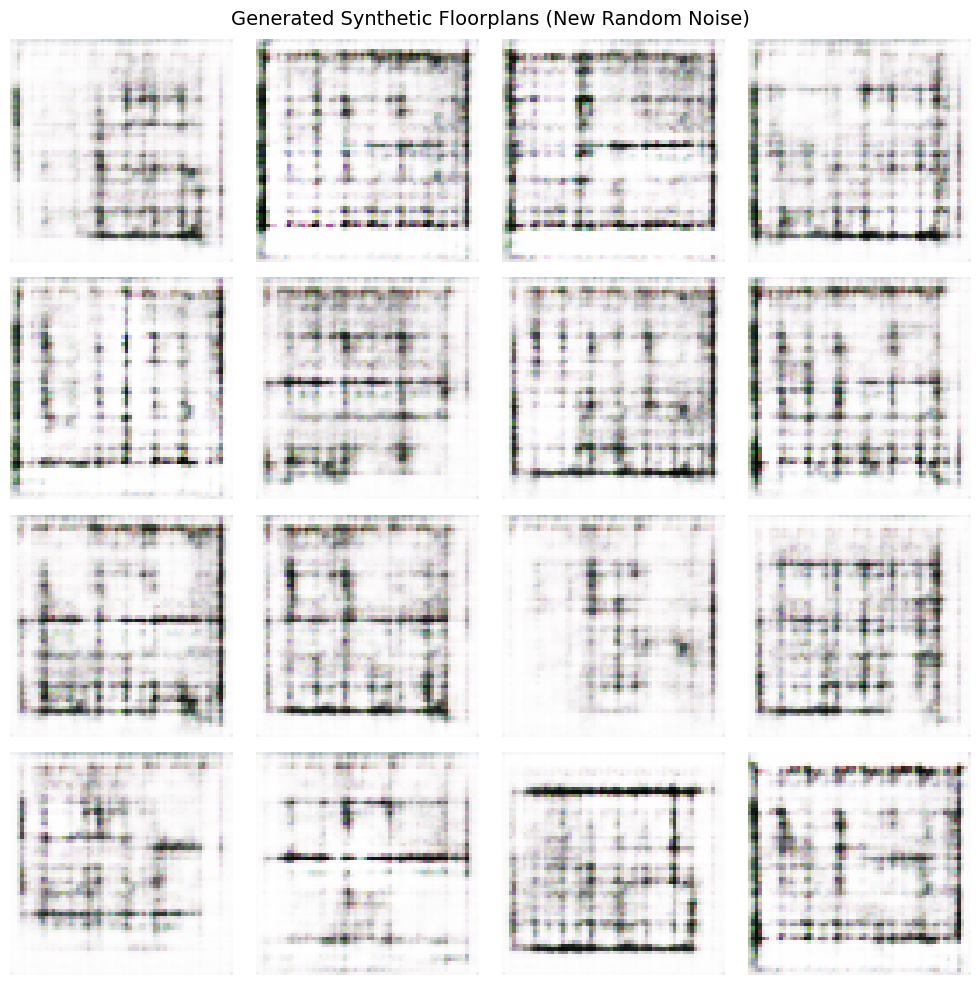

In [ ]:
# Generate a fresh batch of 16 completely new synthetic floorplans
with torch.no_grad():
    new_noise = torch.randn(16, LATENT_DIM, 1, 1, device=device)
    new_floorplans = G(new_noise).cpu()

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    img = new_floorplans[i].permute(1, 2, 0).numpy() * 0.5 + 0.5
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.axis('off')
plt.suptitle("Generated Synthetic Floorplans (New Random Noise)", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Compare Real vs. Generated Floorplans

A side-by-side comparison of real training images and generated images to visually assess how well the GAN has learned the floorplan distribution.

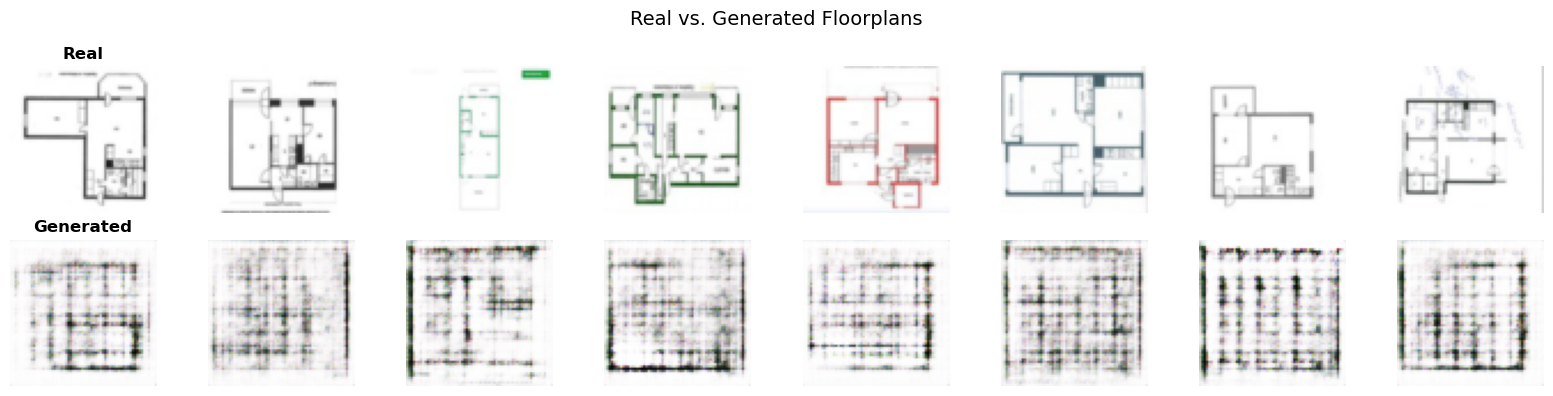

In [ ]:
# Side-by-side: Real vs Generated
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

# Top row: real images
real_batch = next(iter(dataloader))
for i in range(8):
    img = real_batch[i].permute(1, 2, 0).numpy() * 0.5 + 0.5
    axes[0, i].imshow(np.clip(img, 0, 1))
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title("Real", fontsize=12, fontweight='bold')

# Bottom row: generated images
with torch.no_grad():
    z = torch.randn(8, LATENT_DIM, 1, 1, device=device)
    gen_imgs = G(z).cpu()
for i in range(8):
    img = gen_imgs[i].permute(1, 2, 0).numpy() * 0.5 + 0.5
    axes[1, i].imshow(np.clip(img, 0, 1))
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title("Generated", fontsize=12, fontweight='bold')

plt.suptitle("Real vs. Generated Floorplans", fontsize=14)
plt.tight_layout()
plt.show()